Datasets 
1. **Eye Disease Classification (Coursework Workspace)**
* **Link:** [View Dataset](https://universe.roboflow.com/coursework-y7x7o/eye-disease-classification-iu3lf/dataset/2)
* **Explanation:** A dataset focused on single-label classification of various ocular conditions, sourced from academic coursework for multi-class eye disease recognition.
* **Images:** 1,183 images


2. **Eye Disease (Md Nawshin Navin Workspace)**
* **Link:** [View Dataset](https://universe.roboflow.com/md-nawshin-navin/eye-disease-jio2h/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true)
* **Explanation:** An object detection dataset containing labeled images of diseased eyes to assist models in localizing and identifying pathological eye features.
* **Images:** 1,003 images


3. **Eye (AiTech Workspace)**
* **Link:** [View Dataset](https://universe.roboflow.com/aitech-a6cge/eye-ryx7r/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true)
* **Explanation:** A comprehensive object detection dataset featuring diverse eye condition samples aimed at improving generalization across different visual abnormalities.
* **Images:** 2,280 images


4. **Eye Disease (FabricDefect Workspace)**
* **Link:** [View Dataset](https://universe.roboflow.com/fabricdefect-g0o4o/eye-disease-yg5lp)
* **Explanation:** An annotated image dataset tailored for detecting and classifying visual eye defects and diseases using bounding box object detection.
* **Images:** 2,622 images


5. **Eye Disease Detectin (Mirna's Workspace)**
* **Link:** [View Dataset](https://universe.roboflow.com/mirnas-workspace-bgbyl/eye-disease-detectin)
* **Explanation:** A targeted object detection dataset containing multi-angle eye imagery to detect infected or diseased regions within the ocular structure.
* **Images**: 2,297 images



Total Combined Images: 9,385 images

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__images-19-_jpeg_jpg.rf.bcbc755d47d90630239073c6f2d308f9.jpg
/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__images-2023-10-16T130223-599_jpeg_jpg.rf.d7ccfa9df97c417deb19b32578a10267.jpg
/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__istockphoto-1182454350-612x612_jpg.rf.98b9410b045a894b1b6cf12ed34e95bd.jpg
/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__valid__images-88-_jpg.rf.2490e09db5acb5df661f06274341cd3a.jpg
/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__images-96-_jpg.rf.b8c7d0b8ee39bd6be40fc7e3e7192a67.jpg
/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__valid__images-39-_jpg.rf.2b69870b0623cb4cb760701cc4ecb8d8.jpg
/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.

In [2]:
# Step 0 — Path Setup: dataset ka root folder define karta hai aur verify karta hai ke wo exist karta hai
from pathlib import Path

DATA_DIR = Path('/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw')

EXPECTED_CLASSES = {
    'APE': 426, 'Bacterial_Conjunctivitis': 243, 'Cataract': 1861, 'Chalazion': 50,
    'Conjunctivitis': 454, 'Eyelid': 528, 'Foreign_Object': 54, 'Hordeolum': 60,
    'Jaundice': 533, 'Normal': 2612, 'Pinguecula': 54, 'Pterygium': 917,
    'Ptrigio_Pinguecula': 400, 'Uveitis': 222, 'Viral_Conjunctivitis': 1117,
}

print("DATA_DIR exists:", DATA_DIR.exists())
print("Subfolders found:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()) if DATA_DIR.exists() else "N/A")

DATA_DIR exists: True
Subfolders found: ['APE', 'Bacterial_Conjunctivitis', 'Cataract', 'Chalazion', 'Conjunctivitis', 'Eyelid', 'Foreign_Object', 'Hordeolum', 'Jaundice', 'Normal', 'Pinguecula', 'Pterygium', 'Ptrigio_Pinguecula', 'Uveitis', 'Viral_Conjunctivitis']


In [3]:
# Step 1 — Class Count Verify: har class folder ki actual image count nikal ke EXPECTED_CLASSES se compare karta hai
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

actual_counts = {}
for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        n = sum(1 for f in class_dir.iterdir() if f.suffix.lower() in IMG_EXTS)
        actual_counts[class_dir.name] = n

print(f"{'Class':<25}{'Expected':<12}{'Actual':<12}{'Match'}")
for cls, expected in EXPECTED_CLASSES.items():
    actual = actual_counts.get(cls, 0)
    print(f"{cls:<25}{expected:<12}{actual:<12}{'OK' if actual == expected else 'MISMATCH'}")

unexpected = set(actual_counts) - set(EXPECTED_CLASSES)
if unexpected:
    print("\nUnexpected extra folders found:", unexpected)

Class                    Expected    Actual      Match
APE                      426         426         OK
Bacterial_Conjunctivitis 243         243         OK
Cataract                 1861        1861        OK
Chalazion                50          50          OK
Conjunctivitis           454         454         OK
Eyelid                   528         528         OK
Foreign_Object           54          54          OK
Hordeolum                60          60          OK
Jaundice                 533         533         OK
Normal                   2612        2612        OK
Pinguecula               54          54          OK
Pterygium                917         917         OK
Ptrigio_Pinguecula       400         400         OK
Uveitis                  222         222         OK
Viral_Conjunctivitis     1117        1117        OK


In [4]:
# Step 2 — Image Table Build: har image ka path, naam, class, extension aur size ek DataFrame mein daalta hai
import pandas as pd

records = []
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    for f in class_dir.iterdir():
        if f.suffix.lower() in IMG_EXTS:
            records.append({
                'file_path': str(f),
                'file_name': f.name,
                'class': class_dir.name,
                'ext': f.suffix.lower(),
                'size_bytes': f.stat().st_size,
            })

image_df = pd.DataFrame(records)
print("Total images found:", image_df.shape[0])
print(image_df['class'].value_counts())

Total images found: 9531
class
Normal                      2612
Cataract                    1861
Viral_Conjunctivitis        1117
Pterygium                    917
Jaundice                     533
Eyelid                       528
Conjunctivitis               454
APE                          426
Ptrigio_Pinguecula           400
Bacterial_Conjunctivitis     243
Uveitis                      222
Hordeolum                     60
Foreign_Object                54
Pinguecula                    54
Chalazion                     50
Name: count, dtype: int64


In [5]:
# Step 3 — Corrupted Image Check: har image open/verify karta hai, broken files ko drop karta hai
from PIL import Image

corrupted = []
widths, heights, formats = [], [], []

for idx, row in image_df.iterrows():
    try:
        with Image.open(row['file_path']) as im:
            im.verify()
        with Image.open(row['file_path']) as im:
            w, h = im.size
            fmt = im.format
        widths.append(w)
        heights.append(h)
        formats.append(fmt)
    except Exception as e:
        corrupted.append(row['file_path'])
        widths.append(None)
        heights.append(None)
        formats.append(None)

image_df['width'] = widths
image_df['height'] = heights
image_df['format'] = formats

print("Corrupted/unreadable images:", len(corrupted))
for p in corrupted[:10]:
    print(p)

image_df_valid = image_df[~image_df['file_path'].isin(corrupted)].copy()
print("\nValid images remaining:", image_df_valid.shape[0])

Corrupted/unreadable images: 0

Valid images remaining: 9531


In [6]:
# Step 4 — Dimension/Format Audit: image sizes, formats ka summary deta hai aur bohot chotti (<32px) images flag karta hai
print("Format counts:")
print(image_df_valid['format'].value_counts())

print("\nResolution stats:")
print(image_df_valid[['width', 'height']].describe())

tiny = image_df_valid[(image_df_valid['width'] < 32) | (image_df_valid['height'] < 32)]
print("\nSuspiciously tiny images (<32px):", tiny.shape[0])

Format counts:
format
JPEG    9531
Name: count, dtype: int64

Resolution stats:
             width       height
count  9531.000000  9531.000000
mean    557.266499   510.568566
std     395.758360   346.497445
min      41.000000    39.000000
25%     293.000000   213.000000
50%     640.000000   640.000000
75%     640.000000   640.000000
max    5739.000000  4032.000000

Suspiciously tiny images (<32px): 0


In [7]:
# Step 5 — Exact Duplicate Detection: MD5 hash se byte-by-byte identical images dhoondta hai
import hashlib
from collections import defaultdict

def file_md5(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

image_df_valid['md5'] = image_df_valid['file_path'].apply(file_md5)

hash_to_paths = defaultdict(list)
for _, row in image_df_valid.iterrows():
    hash_to_paths[row['md5']].append(row['file_path'])

exact_dupe_groups = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
print("Exact duplicate groups:", len(exact_dupe_groups))
print("Excess copies:", sum(len(v) - 1 for v in exact_dupe_groups.values()))
for h, paths in list(exact_dupe_groups.items())[:5]:
    print(paths)

Exact duplicate groups: 1330
Excess copies: 1546
['/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__test__istockphoto-1215109947-612x612_jpg.rf.4f788bdb83750ad10526644dce66dae9.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/Viral_Conjunctivitis/eye.v1i.yolov8__test__istockphoto-1215109947-612x612_jpg.rf.4f788bdb83750ad10526644dce66dae9.jpg']
['/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__74_webp_jpg.rf.bb07322fc79ad03a92255bda251240b8.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/Normal/eye.v1i.yolov8__train__74_webp_jpg.rf.bb07322fc79ad03a92255bda251240b8.jpg']
['/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__test__images-29-_jpg.rf.eb30c84f2e29eeec0b8b337d7086f047.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/Bacterial_Conjunctivitis/eye.v1i.yolov8__test__images-29-_jpg.rf.eb30c84f2e29eeec0b8b33

In [8]:
# Step 6 — Near-Duplicate Hashing: har image ka perceptual hash (visual fingerprint) nikalta hai
try:
    import imagehash
    HAVE_IMAGEHASH = True
except ImportError:
    HAVE_IMAGEHASH = False
    print("imagehash not installed. Run: pip install imagehash")

phashes = {}
if HAVE_IMAGEHASH:
    for _, row in image_df_valid.iterrows():
        try:
            with Image.open(row['file_path']) as im:
                phashes[row['file_path']] = imagehash.phash(im.convert('L'), hash_size=8)
        except Exception:
            pass

print("Perceptual hashes computed:", len(phashes))


Perceptual hashes computed: 9531


In [9]:
# Step 6b — Near-Dupe Clustering: Hamming distance <=5 wale hashes ko groups mein cluster karta hai
HAMMING_THRESHOLD = 3

paths_list = list(phashes.keys())
parent = {p: p for p in paths_list}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[rx] = ry

for i in range(len(paths_list)):
    for j in range(i + 1, len(paths_list)):
        a, b = paths_list[i], paths_list[j]
        if phashes[a] - phashes[b] <= HAMMING_THRESHOLD:
            union(a, b)

clusters = defaultdict(list)
for p in paths_list:
    clusters[find(p)].append(p)

near_dupe_clusters = {root: members for root, members in clusters.items() if len(members) > 1}
print("Near-duplicate clusters found:", len(near_dupe_clusters))
print("Images involved:", sum(len(m) for m in near_dupe_clusters.values()))
for root, members in list(near_dupe_clusters.items())[:5]:
    print(members)

Near-duplicate clusters found: 1856
Images involved: 4992
['/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__images-19-_jpeg_jpg.rf.bcbc755d47d90630239073c6f2d308f9.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__eyes_3_jpg.rf.01a9f9662dbbe443f8576b351d866f25.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__images-61-_jpg.rf.d9fdaadd0a710c5881cad634fa9a8403.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/Viral_Conjunctivitis/eye.v1i.yolov8__test__istockphoto-179628926-612x612_jpg.rf.96acba86179f0706991c0f5c2a78d900.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/Viral_Conjunctivitis/eye.v1i.yolov8__train__aggravation-working-computer-24829832_webp_jpg.rf.8334264459c2dbb3f000b67880965d69.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/Viral_Conjunctivitis/eye.v1i.yolov8__train__im

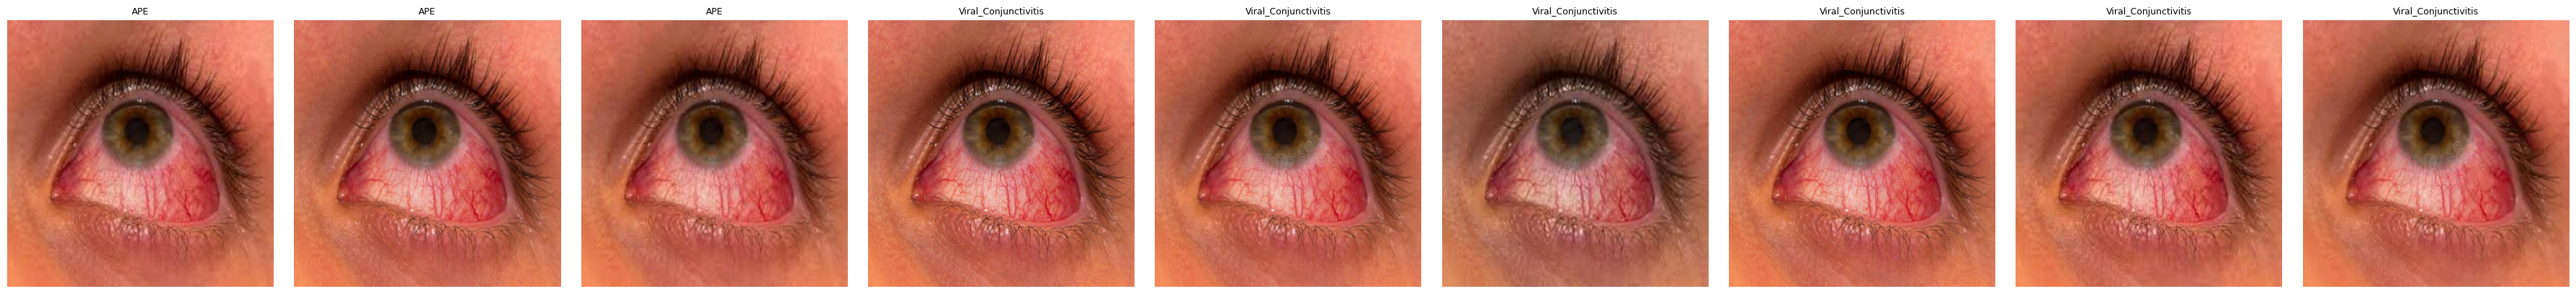

In [10]:
# Visual Check — ek near-duplicate cluster ki saari images side-by-side dikhata hai
import matplotlib.pyplot as plt

sample_cluster = list(near_dupe_clusters.values())[0]  # pehla cluster
n = len(sample_cluster)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1:
    axes = [axes]

for ax, path in zip(axes, sample_cluster):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(Path(path).parent.name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Step 7 — Cross-Class Collision Report: for info only — checks how many duplicate groups span more than one class
path_to_class = dict(zip(image_df_valid['file_path'], image_df_valid['class']))

all_dupe_groups = list(exact_dupe_groups.values())
if HAVE_IMAGEHASH:
    all_dupe_groups += list(near_dupe_clusters.values())

colliding_groups = []
for group in all_dupe_groups:
    classes_in_group = set(path_to_class.get(p) for p in group)
    if len(classes_in_group) > 1:
        colliding_groups.append({'file_paths': group, 'classes': classes_in_group})

print("Duplicate groups spanning more than one class:", len(colliding_groups))
for c in colliding_groups[:10]:
    print(c)

Duplicate groups spanning more than one class: 803
{'file_paths': ['/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__test__istockphoto-1215109947-612x612_jpg.rf.4f788bdb83750ad10526644dce66dae9.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/Viral_Conjunctivitis/eye.v1i.yolov8__test__istockphoto-1215109947-612x612_jpg.rf.4f788bdb83750ad10526644dce66dae9.jpg'], 'classes': {'APE', 'Viral_Conjunctivitis'}}
{'file_paths': ['/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__train__74_webp_jpg.rf.bb07322fc79ad03a92255bda251240b8.jpg', '/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/Normal/eye.v1i.yolov8__train__74_webp_jpg.rf.bb07322fc79ad03a92255bda251240b8.jpg'], 'classes': {'Normal', 'APE'}}
{'file_paths': ['/kaggle/input/datasets/muhammmadsarmad/eye-disease-2/merged_raw/APE/eye.v1i.yolov8__test__images-29-_jpg.rf.eb30c84f2e29eeec0b8b337d7086f047.jpg', '/kaggle/input/datasets/muham

In [12]:
# Step 8 — Duplicate Resolution: keeps one image per duplicate group (same-class or cross-class), drops the rest
drop_paths = set()
for paths in exact_dupe_groups.values():
    for extra in sorted(paths)[1:]:
        drop_paths.add(extra)

if HAVE_IMAGEHASH:
    for members in near_dupe_clusters.values():
        for extra in sorted(members)[1:]:
            drop_paths.add(extra)

image_df_dedup = image_df_valid[~image_df_valid['file_path'].isin(drop_paths)].copy()
duplicates_removed_df = image_df_valid[image_df_valid['file_path'].isin(drop_paths)].copy()

print("Images before dedup:", image_df_valid.shape[0])
print("Images after dedup:", image_df_dedup.shape[0])
print("Duplicates dropped:", len(drop_paths))

Images before dedup: 9531
Images after dedup: 6395
Duplicates dropped: 3136


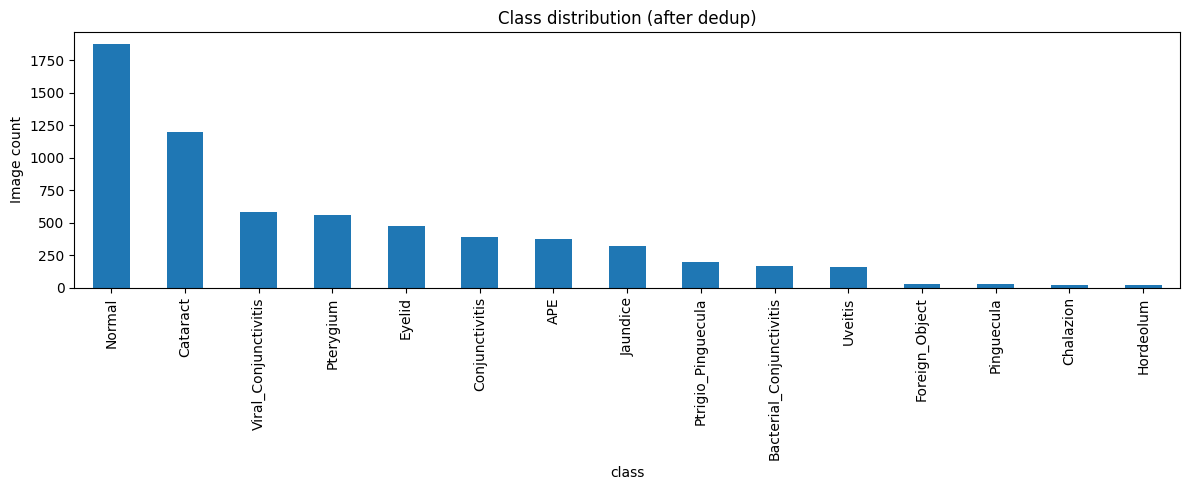

class
Normal                      1873
Cataract                    1195
Viral_Conjunctivitis         585
Pterygium                    560
Eyelid                       475
Conjunctivitis               386
APE                          378
Jaundice                     322
Ptrigio_Pinguecula           200
Bacterial_Conjunctivitis     163
Uveitis                      162
Foreign_Object                27
Pinguecula                    26
Chalazion                     22
Hordeolum                     21
Name: count, dtype: int64

Imbalance ratio (largest / smallest): 89.2
=> Significant imbalance (e.g. Normal vs Chalazion/Pinguecula). Use class_weight,
   and/or oversample the smallest classes -- don't train on raw counts as-is.


In [13]:
# Step 9 — Class Balance Check: plots per-class counts on the deduplicated data and computes the imbalance ratio
import matplotlib.pyplot as plt

class_counts = image_df_dedup['class'].value_counts()
plt.figure(figsize=(12, 5))
class_counts.plot(kind='bar')
plt.ylabel('Image count')
plt.title('Class distribution (after dedup)')
plt.tight_layout()
plt.show()

print(class_counts)
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (largest / smallest): {imbalance_ratio:.1f}")
if imbalance_ratio > 3:
    print("=> Significant imbalance (e.g. Normal vs Chalazion/Pinguecula). Use class_weight,")
    print("   and/or oversample the smallest classes -- don't train on raw counts as-is.")

In [14]:
# Step 10 — Class Weights: computes balanced class weights via sklearn for use during training
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = sorted(image_df_dedup['class'].unique())
labels = image_df_dedup['class'].values

weights = compute_class_weight(class_weight='balanced', classes=np.array(classes), y=labels)
class_weight_dict = {c: w for c, w in zip(classes, weights)}
print("Class weights:")
for c, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    print(f"  {c:<25} {w:.3f}")

Class weights:
  Hordeolum                 20.302
  Chalazion                 19.379
  Pinguecula                16.397
  Foreign_Object            15.790
  Uveitis                   2.632
  Bacterial_Conjunctivitis  2.616
  Ptrigio_Pinguecula        2.132
  Jaundice                  1.324
  APE                       1.128
  Conjunctivitis            1.104
  Eyelid                    0.898
  Pterygium                 0.761
  Viral_Conjunctivitis      0.729
  Cataract                  0.357
  Normal                    0.228


In [15]:
# Step 11 — Final Export: saves the clean deduplicated dataset, the duplicates log, and the cross-class collision log
image_df_dedup.to_csv('/kaggle/working/eye_disease_2_clean_dedup.csv', index=False)
duplicates_removed_df.to_csv('/kaggle/working/eye_disease_2_duplicates_removed.csv', index=False)

if colliding_groups:
    import json as _json
    with open('/kaggle/working/eye_disease_2_class_collisions.json', 'w') as f:
        _json.dump([{'file_paths': c['file_paths'], 'classes': list(c['classes'])} for c in colliding_groups], f, indent=2)

print("Clean dataset exported:", image_df_dedup.shape)
print("Duplicates log exported:", duplicates_removed_df.shape)
print("Class collisions logged:", len(colliding_groups))

assert image_df_dedup['file_path'].is_unique, "Duplicate file_path still present"
assert image_df_dedup['class'].isna().sum() == 0, "Unlabeled images present"
print("All assertions passed")

Clean dataset exported: (6395, 9)
Duplicates log exported: (3136, 9)
Class collisions logged: 803
All assertions passed


In [16]:
# Step 12 — Final Summary: prints the final total image count after preprocessing
print("Final total images in cleaned dataset:", image_df_dedup.shape[0])
print(image_df_dedup['class'].value_counts())

Final total images in cleaned dataset: 6395
class
Normal                      1873
Cataract                    1195
Viral_Conjunctivitis         585
Pterygium                    560
Eyelid                       475
Conjunctivitis               386
APE                          378
Jaundice                     322
Ptrigio_Pinguecula           200
Bacterial_Conjunctivitis     163
Uveitis                      162
Foreign_Object                27
Pinguecula                    26
Chalazion                     22
Hordeolum                     21
Name: count, dtype: int64


In [17]:
# Step 12 — Flag stock/infographic-style images (text overlays, collages) via OCR
!pip install pytesseract -q
!apt-get install -y tesseract-ocr -q > /dev/null

import pytesseract
from PIL import Image
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

def detect_text_in_image(file_path, min_chars=4):
    """Returns detected text if image contains readable text overlay, else empty string."""
    try:
        img = Image.open(file_path).convert("RGB")
        text = pytesseract.image_to_string(img).strip()
        # filter out tiny noise/garbage OCR reads
        text = " ".join(text.split())
        if len(text) >= min_chars:
            return text
        return ""
    except Exception as e:
        return f"ERROR: {e}"

# Run OCR across the whole cleaned dataset (this can take a while for thousands of images)
image_df_dedup['ocr_text'] = image_df_dedup['file_path'].progress_apply(detect_text_in_image)

# Flag rows where meaningful text was detected
suspicious_df = image_df_dedup[
    (image_df_dedup['ocr_text'] != "") &
    (~image_df_dedup['ocr_text'].str.startswith("ERROR"))
].copy()

print(f"Suspicious (possible text-overlay/infographic) images found: {len(suspicious_df)} / {len(image_df_dedup)}")
print(suspicious_df[['file_path', 'class', 'ocr_text']].head(20))

suspicious_df.to_csv('/kaggle/working/suspicious_text_overlay_images.csv', index=False)

100%|██████████| 6395/6395 [30:37<00:00,  3.48it/s]

Suspicious (possible text-overlay/infographic) images found: 241 / 6395
                                             file_path  \
16   /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
32   /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
46   /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
65   /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
119  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
133  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
135  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
174  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
184  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
199  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
206  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
300  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
320  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
347  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   
473  /kaggle/input/datasets/muhammmadsarmad/eye-dis...   


In [18]:
# Step X — Build review grids (40 images per batch) with OCR text captions
import matplotlib.pyplot as plt
import math

def make_review_grid(df, batch_size=40, cols=5, save_prefix='/kaggle/working/review_batch'):
    n_batches = math.ceil(len(df) / batch_size)
    for b in range(n_batches):
        batch = df.iloc[b*batch_size : (b+1)*batch_size]
        rows = math.ceil(len(batch) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.6))
        axes = axes.flatten()

        for ax, (_, row) in zip(axes, batch.iterrows()):
            try:
                img = Image.open(row['file_path']).convert("RGB")
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "Load error", ha='center', va='center')
            caption = f"{row['class']}\n\"{row['ocr_text'][:40]}\""
            ax.set_title(caption, fontsize=7)
            ax.axis('off')

        # hide unused subplots
        for ax in axes[len(batch):]:
            ax.axis('off')

        plt.tight_layout()
        out_path = f"{save_prefix}_{b+1}.png"
        plt.savefig(out_path, dpi=120, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved {out_path} ({len(batch)} images)")

make_review_grid(suspicious_df, batch_size=40, cols=5)

Saved /kaggle/working/review_batch_1.png (40 images)
Saved /kaggle/working/review_batch_2.png (40 images)
Saved /kaggle/working/review_batch_3.png (40 images)
Saved /kaggle/working/review_batch_4.png (40 images)
Saved /kaggle/working/review_batch_5.png (40 images)
Saved /kaggle/working/review_batch_6.png (40 images)
Saved /kaggle/working/review_batch_7.png (1 images)


In [19]:
# Step X — Drop flagged web/stock/infographic images and re-export clean dataset
print("Before drop:", image_df_dedup.shape)

image_df_dedup_final = image_df_dedup[
    ~image_df_dedup['file_path'].isin(suspicious_df['file_path'])
].reset_index(drop=True)

print("After drop:", image_df_dedup_final.shape)
print("Dropped:", image_df_dedup.shape[0] - image_df_dedup_final.shape[0])

print("\nNew class distribution:")
print(image_df_dedup_final['class'].value_counts())

# Save the dropped ones separately as a log (in case you want to double-check later)
suspicious_df.to_csv('/kaggle/working/eye_disease_2_web_images_removed.csv', index=False)

# Re-export the final cleaned dataset
image_df_dedup_final.to_csv('/kaggle/working/eye_disease_2_clean_final.csv', index=False)

assert image_df_dedup_final['file_path'].is_unique, "Duplicate file_path still present"
assert image_df_dedup_final['class'].isna().sum() == 0, "Unlabeled images present"
print("\nAll assertions passed — final dataset ready:", image_df_dedup_final.shape)

Before drop: (6395, 10)
After drop: (6154, 10)
Dropped: 241

New class distribution:
class
Normal                      1823
Cataract                    1172
Viral_Conjunctivitis         547
Pterygium                    543
Eyelid                       468
Conjunctivitis               381
APE                          364
Jaundice                     263
Ptrigio_Pinguecula           195
Uveitis                      157
Bacterial_Conjunctivitis     156
Foreign_Object                24
Chalazion                     22
Hordeolum                     20
Pinguecula                    19
Name: count, dtype: int64

All assertions passed — final dataset ready: (6154, 10)
